# 用 sympy 解三次方程 x³ - 2x + 1 = 0 并绘图

这个方程是一个三次方程，先用 sympy 求出它的解析根，再在同一坐标系里画出函数曲线，标出根的位置。数据完全由表达式生成，不依赖外部文件。

In [1]:
import sympy as sp

x = sp.symbols('x')
expr = x**3 - 2*x + 1

# 尝试因式分解，看是否有整数根
print("因式分解：", sp.factor(expr))

# 求所有根（精确形式）
roots = sp.solve(expr, x)
print("\n解析根（精确形式）：")
for r in roots:
    print(r)

# 打印数值近似
print("\n根的数值近似：")
for r in roots:
    print(sp.N(r))

因式分解： (x - 1)*(x**2 + x - 1)

解析根（精确形式）：
1
-1/2 + sqrt(5)/2
-sqrt(5)/2 - 1/2

根的数值近似：
1.00000000000000
0.618033988749895
-1.61803398874989


## 绘制函数曲线与根的位置

画出 f(x) = x³ - 2x + 1 在包含全部三个根的区间上的图像，用红点标出根，横轴作为参考线。

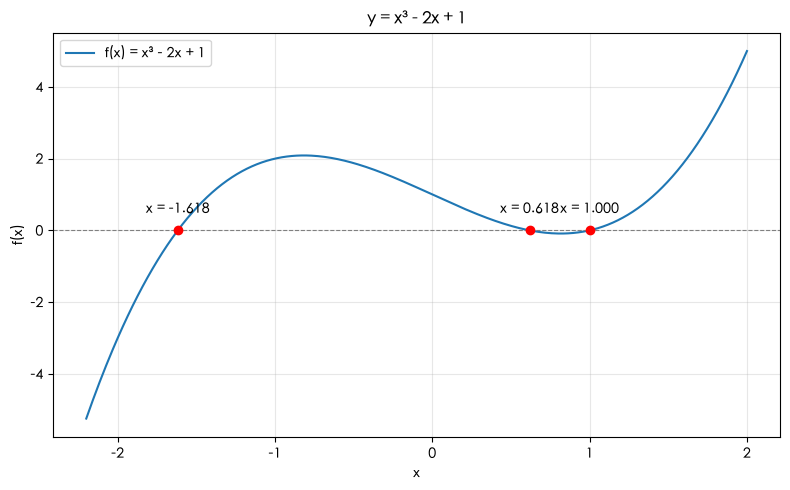

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

x = sp.symbols('x')
expr = x**3 - 2*x + 1

# 转为 numpy 可计算的函数
f = sp.lambdify(x, expr, 'numpy')

# 三个根（精确值），转成浮点用于绘图标注
roots = [sp.N(r) for r in sp.solve(expr, x)]
root_vals = [float(r) for r in roots]

xs = np.linspace(-2.2, 2.0, 400)
ys = f(xs)

plt.figure(figsize=(8, 5))
plt.plot(xs, ys, label='f(x) = x³ - 2x + 1')
plt.axhline(0, color='gray', linewidth=0.8, linestyle='--')
plt.scatter(root_vals, [0, 0, 0], color='red', zorder=3)

for rv in root_vals:
    plt.annotate(f'x = {rv:.3f}', (rv, 0),
                 textcoords='offset points', xytext=(0, 12), ha='center')

plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('y = x³ - 2x + 1')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 小结

方程 x³ - 2x + 1 = 0 可因式分解为 (x - 1)(x² + x - 1)，因此三个根分别是：

- x = 1
- x = (√5 - 1)/2 ≈ 0.618
- x = -(√5 + 1)/2 ≈ -1.618

曲线图直观显示这三个根正好是曲线与 x 轴的交点，其中 x = 1 处曲线从左下到右上穿过（局部递增），另外两个根分别位于原点两侧。